/tmp/ipykernel_2558/2595887076.py:60: RuntimeWarning: divide by zero encountered in divide
  ratio = np.where(local_var > 0, noise_var / local_var, 0)


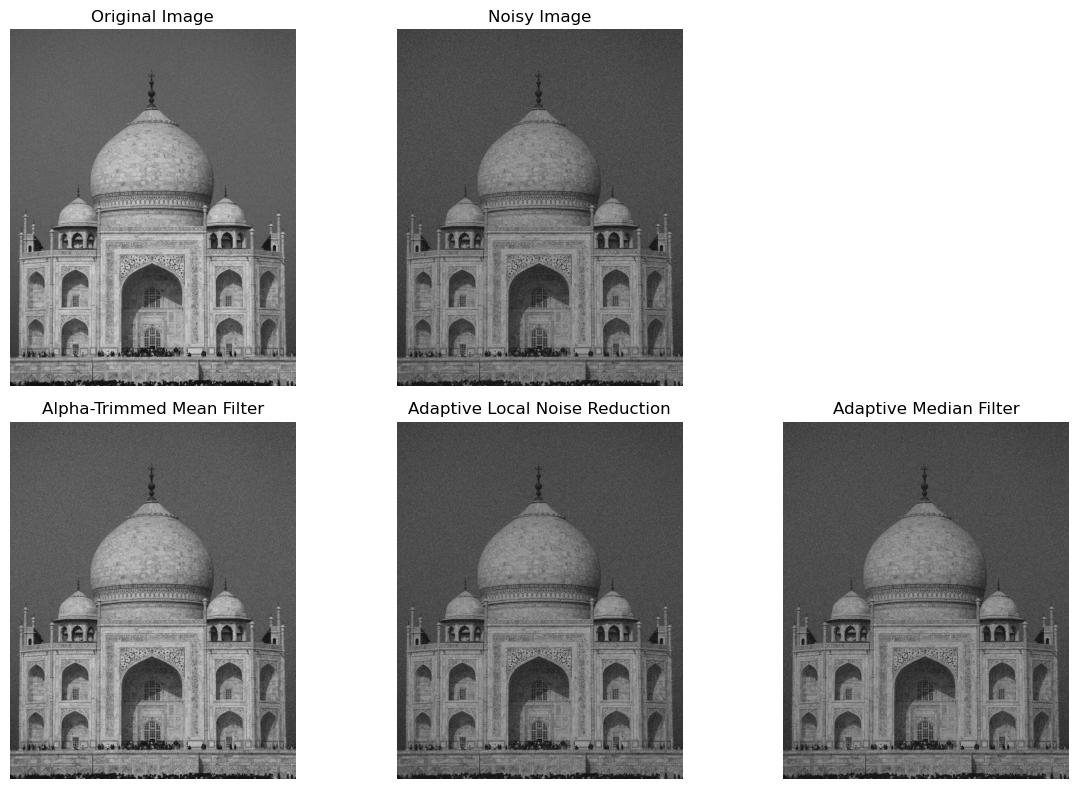

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the grayscale image
image = cv2.imread("ImageEnhancement/taj_grey.jpg", cv2.IMREAD_GRAYSCALE)

# Function to add Salt & Pepper noise
def add_salt_pepper_noise(img, salt_prob, pepper_prob):
    noisy = img.copy()
    total_pixels = img.size
    num_salt = int(total_pixels * salt_prob)
    num_pepper = int(total_pixels * pepper_prob)

    # Add salt (white) noise
    salt_coords = np.random.choice(total_pixels, num_salt, replace=False)
    noisy.flat[salt_coords] = 255

    # Add pepper (black) noise
    pepper_coords = np.random.choice(total_pixels, num_pepper, replace=False)
    noisy.flat[pepper_coords] = 0

    return noisy

# Function to add Gaussian noise
def add_gaussian_noise(img, mean=0, std=25):
    gaussian_noise = np.random.normal(mean, std, img.shape).astype(np.float32)
    noisy_img = img.astype(np.float32) + gaussian_noise
    return np.clip(noisy_img, 0, 255).astype(np.uint8)

# Apply Salt & Pepper and Gaussian Noise
noisy_img = add_salt_pepper_noise(image, 0.02, 0.02)
noisy_img = add_gaussian_noise(noisy_img)

# Alpha-Trimmed Mean Filter
def alpha_trimmed_mean_filter(img, d=2, kernel_size=3):
    assert d % 2 == 0, "d must be even"
    pad_size = kernel_size // 2
    padded_img = cv2.copyMakeBorder(img, pad_size, pad_size, pad_size, pad_size, cv2.BORDER_REFLECT)
    filtered_img = np.zeros_like(img, dtype=np.float32)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            window = padded_img[i:i+kernel_size, j:j+kernel_size].flatten()
            window.sort()
            trimmed = window[d//2 : -d//2]  # Remove d/2 elements from both ends
            filtered_img[i, j] = np.mean(trimmed)

    return np.clip(filtered_img, 0, 255).astype(np.uint8)

# Adaptive Local Noise Reduction Filter
def adaptive_local_noise_reduction(img, noise_var=20):
    img = img.astype(np.float32)
    kernel_size = 3
    local_mean = cv2.boxFilter(img, ddepth=-1, ksize=(kernel_size, kernel_size))
    local_var = cv2.boxFilter(img**2, ddepth=-1, ksize=(kernel_size, kernel_size)) - local_mean**2
    local_var = np.maximum(local_var, 0)  # Ensure non-negative variance

    # Compute the ratio noise_var / local_var, handling division by zero
    ratio = np.where(local_var > 0, noise_var / local_var, 0)
    result = img - ratio * (img - local_mean)

    return np.clip(result, 0, 255).astype(np.uint8)

# Adaptive Median Filter
def adaptive_median_filter(img, max_kernel_size=7):
    img = img.astype(np.float32)
    filtered_img = np.copy(img)

    for kernel_size in range(3, max_kernel_size + 1, 2):
        pad_size = kernel_size // 2
        padded_img = cv2.copyMakeBorder(filtered_img, pad_size, pad_size, pad_size, pad_size, cv2.BORDER_REFLECT)

        for i in range(img.shape[0]):
            for j in range(img.shape[1]):
                x, y = i + pad_size, j + pad_size
                window = padded_img[x-pad_size:x+pad_size+1, y-pad_size:y+pad_size+1]
                z_min = np.min(window)
                z_max = np.max(window)
                z_med = np.median(window)
                z_xy = padded_img[x, y]

                if z_min < z_med < z_max:
                    if z_min < z_xy < z_max:
                        filtered_img[i, j] = z_xy
                    else:
                        filtered_img[i, j] = z_med
                    break
                else:
                    continue

    return np.clip(filtered_img, 0, 255).astype(np.uint8)

# Apply filters
alpha_trimmed_img = alpha_trimmed_mean_filter(noisy_img, d=2, kernel_size=3)
adaptive_local_denoised_img = adaptive_local_noise_reduction(noisy_img, noise_var=20)
adaptive_median_denoised_img = adaptive_median_filter(noisy_img, max_kernel_size=7)

# Display results
plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.title("Original Image")
plt.imshow(image, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.title("Noisy Image")
plt.imshow(noisy_img, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.title("Alpha-Trimmed Mean Filter")
plt.imshow(alpha_trimmed_img, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.title("Adaptive Local Noise Reduction")
plt.imshow(adaptive_local_denoised_img, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.title("Adaptive Median Filter")
plt.imshow(adaptive_median_denoised_img, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()
